In [43]:


import pandas as pd
path_data_dir = "../../data/inputs/" 
train_data_file = path_data_dir + "hoteles-entrena.csv" 
test_data_file = path_data_dir + "hoteles-prueba.csv"
#train data reanding
train_data = pd.read_csv(train_data_file, sep=",")
print('')
print('train data info:')
train_data.info()
test_data = pd.read_csv(test_data_file, sep=",")
print('')
print('test data info:')
test_data.info()


train data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52981 entries, 0 to 52980
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           52981 non-null  object 
 1   lead_time                       52981 non-null  int64  
 2   stays_in_weekend_nights         52981 non-null  int64  
 3   stays_in_week_nights            52981 non-null  int64  
 4   adults                          52981 non-null  int64  
 5   children                        52981 non-null  object 
 6   meal                            52981 non-null  object 
 7   country                         52681 non-null  object 
 8   market_segment                  52981 non-null  object 
 9   distribution_channel            52981 non-null  object 
 10  is_repeated_guest               52981 non-null  int64  
 11  previous_cancellations          52981 non-null  int64  
 12  previous_booki

In [44]:
train_data['lead_time']

0        342
1        737
2          7
3         13
4         14
        ... 
52976     23
52977    102
52978     34
52979    109
52980    205
Name: lead_time, Length: 52981, dtype: int64

In [45]:
train_data.head(3)  

,hotel,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,meal,country,market_segment,distribution_channel,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests,arrival_date
0,Resort_Hotel,342,0,0,2,none,BB,PRT,Direct,Direct,...,3,No_Deposit,NaN,NaN,0,Transient,0.0,none,0,2015-07-01
1,Resort_Hotel,737,0,0,2,none,BB,PRT,Direct,Direct,...,4,No_Deposit,NaN,NaN,0,Transient,0.0,none,0,2015-07-01
2,Resort_Hotel,7,0,1,1,none,BB,GBR,Direct,Direct,...,0,No_Deposit,NaN,NaN,0,Transient,75.0,none,0,2015-07-01


In [46]:

# Count unique values in 'meal' and put them into a DataFrame
train_meal_counts = train_data['meal'].value_counts().reset_index()
train_meal_counts['%'] = train_meal_counts['count']/sum(train_meal_counts['count'])
train_meal_counts.columns = ['meal', 'count', '%']
print(train_meal_counts)
print('')
# Count unique values in 'meal' and put them into a DataFrame
test_meal_counts = test_data['meal'].value_counts().reset_index()
test_meal_counts['%'] = test_meal_counts['count']/sum(test_meal_counts['count'])
test_meal_counts.columns = ['meal', 'count', '%']
print(test_meal_counts)


        meal  count         %
0         BB  40865  0.771314
1         HB   6624  0.125026
2         SC   4637  0.087522
3  Undefined    632  0.011929
4         FB    223  0.004209

        meal  count         %
0         BB  16935  0.763354
1         HB   2855  0.128691
2         SC   2047  0.092270
3  Undefined    251  0.011314
4         FB     97  0.004372


In [47]:
# Check if 'meal' is 'SC' or 'Undefined' and if there are children (children != 'none')
mask = train_data['meal'].isin(['SC', 'Undefined']) & (train_data['children'] != 'none')
coincidence_count = mask.sum()
total_sc_undefined = train_data['meal'].isin(['SC', 'Undefined']).sum()
print(f"Number of cases where meal is SC or Undefined and there are children: {coincidence_count}")
print(f"Total cases with meal SC or Undefined: {total_sc_undefined}")
print(f"Proportion: {coincidence_count / total_sc_undefined:.4f}")
# Check coincidence for each meal type: BB, HB, FB
for meal_type in ['BB', 'HB', 'FB']:
    mask_meal = (train_data['meal'] == meal_type) & (train_data['children'] != 'none')
    coincidence = mask_meal.sum()
    total_meal = (train_data['meal'] == meal_type).sum()
    proportion = coincidence / total_meal if total_meal > 0 else 0
    print(f"Meal: {meal_type}")
    print(f"  Number of cases with children: {coincidence}")
    print(f"  Total cases: {total_meal}")
    print(f"  Proportion: {proportion:.4f}")


Number of cases where meal is SC or Undefined and there are children: 146
Total cases with meal SC or Undefined: 5269
Proportion: 0.0277
Meal: BB
  Number of cases with children: 3480
  Total cases: 40865
  Proportion: 0.0852
Meal: HB
  Number of cases with children: 665
  Total cases: 6624
  Proportion: 0.1004
Meal: FB
  Number of cases with children: 43
  Total cases: 223
  Proportion: 0.1928


In [48]:
# Extract weeks in year and time span from stays_in_week_nights and stays_in_weekends_nights

# For train_data
train_data['total_nights'] = train_data['stays_in_week_nights'] + train_data['stays_in_weekend_nights']
train_data['weeks_in_year'] = ((train_data['total_nights'] / 7).round().clip(lower=1, upper=52)).astype(int)
#train_data['time_span'] = train_data['total_nights']
train_data['arrival_week'] = pd.to_datetime(train_data['arrival_date']).dt.isocalendar().week
train_data['arrival_week'] = train_data['arrival_week'].astype('int64')

# For test_data
test_data['total_nights'] = test_data['stays_in_week_nights'] + test_data['stays_in_weekend_nights']
test_data['weeks_in_year'] = ((test_data['total_nights'] / 7).round().clip(lower=1, upper=52)).astype(int)
#test_data['time_span'] = test_data['total_nights']
test_data['arrival_week'] = pd.to_datetime(test_data['arrival_date']).dt.isocalendar().week
test_data['arrival_week'] = test_data['arrival_week'].astype('int64')

In [49]:
train_data.loc[train_data['meal'] == 'Undefined', 'meal'] = 'SC'
test_data.loc[test_data['meal'] == 'Undefined', 'meal'] = 'SC'
# Count unique values in 'meal' and put them into a DataFrame
train_meal_counts = train_data['meal'].value_counts().reset_index()
train_meal_counts['%'] = train_meal_counts['count']/sum(train_meal_counts['count'])
train_meal_counts.columns = ['meal', 'count', '%']
print(train_meal_counts)
print('')
# Count unique values in 'meal' and put them into a DataFrame
test_meal_counts = test_data['meal'].value_counts().reset_index()
test_meal_counts['%'] = test_meal_counts['count']/sum(test_meal_counts['count'])
test_meal_counts.columns = ['meal', 'count', '%']
print(test_meal_counts)


  meal  count         %
0   BB  40865  0.771314
1   HB   6624  0.125026
2   SC   5269  0.099451
3   FB    223  0.004209

  meal  count         %
0   BB  16935  0.763354
1   HB   2855  0.128691
2   SC   2298  0.103584
3   FB     97  0.004372


In [50]:
# Create new columns for meal types HB, SC, FB
train_data['meal_HB'] = (train_data['meal'] == 'HB').astype(int)
train_data['meal_SC'] = (train_data['meal'] == 'SC').astype(int)
train_data['meal_FB'] = (train_data['meal'] == 'FB').astype(int)
train_data['meal_BB'] = (train_data['meal'] == 'BB').astype(int)
train_data.drop('meal', axis=1, inplace=True)  # Drop BB to avoid multicollinearity

test_data['meal_HB'] = (test_data['meal'] == 'HB').astype(int)
test_data['meal_SC'] = (test_data['meal'] == 'SC').astype(int)
test_data['meal_FB'] = (test_data['meal'] == 'FB').astype(int)
test_data['meal_BB'] = (test_data['meal'] == 'BB').astype(int)
test_data.drop('meal', axis=1, inplace=True) # Drop BB to avoid multicollinearity

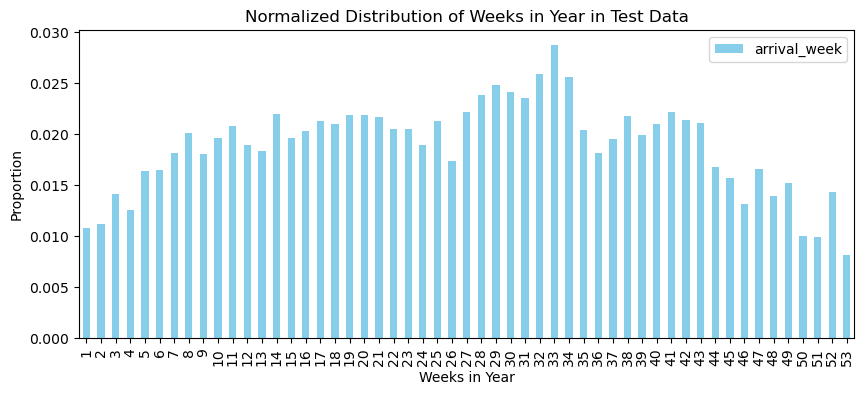

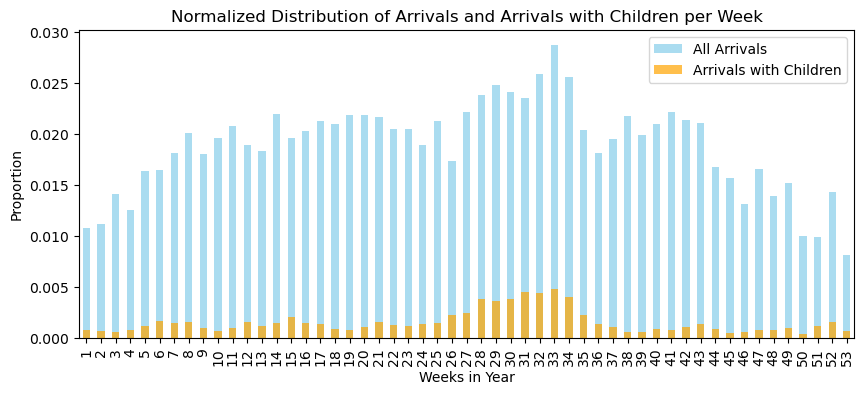

In [51]:
import matplotlib.pyplot as plt

# Plot normalized distribution of arrival_week
(train_data['arrival_week'].value_counts(normalize=True)
    .sort_index()
    .plot(kind='bar', figsize=(10, 4), color='skyblue', label='arrival_week'))
plt.xlabel('Weeks in Year')
plt.ylabel('Proportion')
plt.title('Normalized Distribution of Weeks in Year in Test Data')
plt.legend()
plt.show()

# Count number of arrivals with children per week
children_per_week = train_data[train_data['children'] != 'none'].groupby('arrival_week').size()
total_per_week = train_data.groupby('arrival_week').size()

# Plot both on the same bar plot
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot total arrivals per week
(total_per_week / total_per_week.sum()).plot(kind='bar', color='skyblue', alpha=0.7, label='All Arrivals', ax=ax1)

# Plot arrivals with children per week
(children_per_week / total_per_week.sum()).reindex(total_per_week.index, fill_value=0).plot(
    kind='bar', color='orange', alpha=0.7, label='Arrivals with Children', ax=ax1
)

plt.xlabel('Weeks in Year')
plt.ylabel('Proportion')
plt.title('Normalized Distribution of Arrivals and Arrivals with Children per Week')
plt.legend()
plt.show()

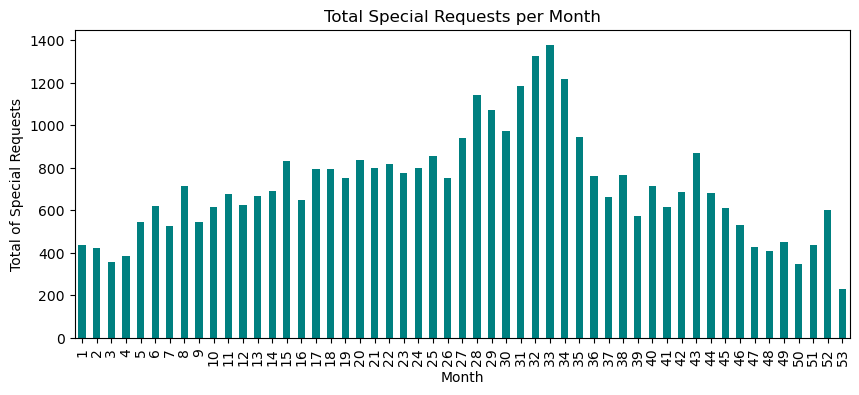

In [52]:
# Extract month from arrival_date
# Extract week from arrival_date (already exists as 'arrival_week')
# Group by week and sum total_of_special_requests
weekly_special_requests = train_data.groupby('arrival_week')['total_of_special_requests'].sum()


# Plot
weekly_special_requests.plot(kind='bar', color='teal', figsize=(10, 4))
plt.xlabel('Month')
plt.ylabel('Total of Special Requests')
plt.title('Total Special Requests per Month')
plt.show()


In [53]:
from dateutil.easter import easter

# Add "school_vacations" column: 1 if arrival_date is in December, June, July, August, or Easter week

def is_school_vacation(date_str):
    date = pd.to_datetime(date_str, errors='coerce')
    if pd.isna(date):
        return 0
    # Months: December (12), June (6), July (7), August (8)
    if date.month in [6, 7, 8, 12]:
        return 1
    # Easter: calculate Easter Sunday and check if date is in Easter week (Sunday to Saturday)
    easter_sunday = easter(date.year)
    easter_week = pd.date_range(easter_sunday - pd.Timedelta(days=easter_sunday.weekday()+1), periods=7)
    if date in easter_week:
        return 1
    return 0

train_data['school_vacations'] = train_data['arrival_date'].apply(is_school_vacation)
test_data['school_vacations'] = test_data['arrival_date'].apply(is_school_vacation)



In [54]:
## create ne column that combines arrival week and school_vacations
train_data['week_vacation'] = train_data['arrival_week'].astype('int64') * train_data['school_vacations'].astype('int64')
test_data['week_vacation'] = test_data['arrival_week'].astype('int64') * test_data['school_vacations'].astype('int64')

In [55]:
# convert column 'hotel' to numeric value.
train_data['hotel']= train_data['hotel'].apply(lambda x: 1 if x == 'H1' else 0)
test_data['hotel']= test_data['hotel'].apply(lambda x: 1 if x == 'H1' else 0)

#train_data['Hotel and vacations'] = train_data['hotel']*train_data['school_vacations'].astype(int)
#test_data['Hotel and vacations'] = test_data['hotel']*train_data['school_vacations'].astype(int)

#train_data['Hotel and vacations'] = train_data['Hotel and vacations'].astype(int)
#test_data['Hotel and vacations'] = train_data['Hotel and vacations'].astype(int)

In [56]:
print(train_data.info())
print('')
print(test_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52981 entries, 0 to 52980
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           52981 non-null  int64  
 1   lead_time                       52981 non-null  int64  
 2   stays_in_weekend_nights         52981 non-null  int64  
 3   stays_in_week_nights            52981 non-null  int64  
 4   adults                          52981 non-null  int64  
 5   children                        52981 non-null  object 
 6   country                         52681 non-null  object 
 7   market_segment                  52981 non-null  object 
 8   distribution_channel            52981 non-null  object 
 9   is_repeated_guest               52981 non-null  int64  
 10  previous_cancellations          52981 non-null  int64  
 11  previous_bookings_not_canceled  52981 non-null  int64  
 12  reserved_room_type              

In [57]:
#train_data['Hotel and vacations']

In [58]:
train_data['children'] = train_data['children'].apply(lambda x: 0 if x == 'none' else 1)
#type(train_data['children'])

In [59]:
missing_in_test = set(train_data.columns) - set(test_data.columns)
print("Columns in train_data but not in test_data:", missing_in_test)

Columns in train_data but not in test_data: {'children'}


In [ ]:
# Convert children to numeric
train_data['children'] = pd.to_numeric(train_data['children'], errors='coerce')

# Define target: presence of children (0 or 1)
train_data['has_children'] = (train_data['children'] > 0).astype(int)
y = train_data['has_children']
#train_data['children'].isna().sum()

0

In [61]:
# save preprocessed data to new csv files
path_data_dir = "../../data/preprocessed/"
train_data.to_csv(path_data_dir + "hoteles_train_preprocessed.csv", index=False)
test_data.to_csv(path_data_dir + "hoteles_test_preprocessed.csv", index=False)